# 03 — Decision: from a probability to a lending policy

**Goal.** Turn the lasso's default probability into an accept/refuse decision for each application,
and measure what that decision earns in dollars.

Notebook 02 showed the probabilities are calibrated: 20 % means 20 %. That is what licenses this
notebook — every dollar figure below is built on the *level* of the probabilities, not just on their
ordering.

---

**Two uses of profit, never mixed.**

| | **Decide** (ex ante) | **Evaluate** (ex post) |
|---|---|---|
| Question | Should this loan be granted? | What did the policy actually earn? |
| Information allowed | Only what is known at application time | Everything that happened |
| Gain if repaid | $G_i = \kappa_T \times$ scheduled interest | — |
| Loss if default | $L_i = \text{LGD}_T \times$ amount lent | — |
| Realised profit | — | cash received $-$ amount lent |

Using realised amounts inside the decision rule would be a leak, exactly like a post-decision
column among the features. To evaluate, on the other hand, realised amounts are the ground truth,
just like `y`.

$\kappa_T$ and $\text{LGD}_T$ were estimated **on the training set** in notebook 01 (§9 bis) and are
only read here: everything that fits lives in notebook 01, everything that measures lives in 02 and 03.

*No discounting*: over 3 to 5 years with near-zero rates (2015–2018) it is a second-order effect,
stated in the README limitations.

## 0. Environment

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = '/content/drive/MyDrive/credit-decision'
    IN_COLAB = True
except ImportError:          # local run, from the notebooks/ folder
    ROOT = '..'
    IN_COLAB = False

ART = f'{ROOT}/artefacts'                                   # regenerable, never versioned
FIG = f'{ROOT}/figures' if IN_COLAB else f'{ROOT}/reports/figures'
os.makedirs(ART, exist_ok=True)
os.makedirs(FIG, exist_ok=True)
print(ART)

Mounted at /content/drive
/content/drive/MyDrive/credit-decision/artefacts


## 1. Loading

Two files, both produced by notebook 01: the test loans with their amounts, Lending Club grades and
lasso probability; and the two profit parameters per loan term, estimated on the training set.

In [2]:
dec = pd.read_parquet(f'{ART}/decision_test.parquet')
with open(f'{ART}/profit_params.json') as f:
    params = {int(k): v for k, v in json.load(f).items()}

dec['T'] = dec['term'].str.extract(r'(\d+)')[0].astype(int)
assert set(dec['T']) <= set(params), "a loan term has no profit parameters"
assert dec['proba_lasso'].between(0, 1).all()

print(dec.shape, f"| pi = {dec['y'].mean():.3f}")
print(dec['T'].value_counts().sort_index().to_dict())
print(params)

(75029, 15) | pi = 0.202
{36: 56377, 60: 18652}
{36: {'LGD': 0.38721128898028934, 'kappa': 0.8024427714449447}, 60: {'LGD': 0.47385210411581935, 'kappa': 0.5199025236430233}}


## 2. Two profit functions

**Ex ante — what the decision is allowed to know.**

- Scheduled interest: $I_i = T \cdot m_i - A_i$ (all instalments minus the amount lent).
- Gain if repaid: $G_i = \kappa_T \, I_i$. Since $\kappa < 1$, it accounts on average for early
  repayments, which cut the interest actually collected.
- Loss if default: $L_i = \text{LGD}_T \, A_i$. The LGD here is a loss rate **on the amount lent**,
  net of the instalments paid before default and of recoveries — not the Basel LGD, which is a loss
  rate on the exposure at default.
- Expected profit: $\mathbb{E}[\Pi_i] = (1-p_i)\,G_i - p_i\,L_i$.

**Ex post — what actually happened.** Realised profit $=$ `total_pymnt` $-$
`collection_recovery_fee` $-$ `funded_amnt`. Notebook 01 checked that `total_pymnt` already
includes recoveries, so nothing is counted twice; the collection agency's fee (about 18 % of
recoveries) is a genuine cost and is deducted.

**Consistency filter.** The instalment of an amortising loan is fixed by the contract:
$m = A\,r/(1-(1+r)^{-T})$. Recomputing it from `funded_amnt`, `int_rate` and the term matches
Lending Club's `installment` within 1 % for 99.97 % of test loans — which also validates the
formula. The handful of loans that do not match (two of them even have instalments summing to less
than the amount lent, i.e. negative interest) are data errors: they are dropped, and their number
is printed.


In [3]:
lgd   = dec['T'].map({T: v['LGD'] for T, v in params.items()})
kappa = dec['T'].map({T: v['kappa'] for T, v in params.items()})

# --- consistency filter: the instalment must match the contract (amount, rate, term) ---
rm = dec['int_rate'] / 1200
m_theo = dec['funded_amnt'] * rm / (1 - (1 + rm) ** (-dec['T']))
consistent = (dec['installment'] / m_theo - 1).abs() < 0.01
print(f"instalment within 1 % of the annuity formula: {consistent.mean():.4%}")
print(f"dropped as inconsistent: {(~consistent).sum()} loans")
dec = dec[consistent].copy()
lgd, kappa = lgd[consistent], kappa[consistent]

dec['sched_int'] = dec['installment'] * dec['T'] - dec['funded_amnt']
dec['G'] = kappa * dec['sched_int']
dec['L'] = lgd * dec['funded_amnt']
dec['exp_profit'] = (1 - dec['proba_lasso']) * dec['G'] - dec['proba_lasso'] * dec['L']
dec['real_profit'] = dec['total_pymnt'] - dec['collection_recovery_fee'] - dec['funded_amnt']

assert (dec['sched_int'] > 0).all(), "negative scheduled interest: check installment / term"
dec[['funded_amnt', 'sched_int', 'G', 'L', 'exp_profit', 'real_profit']].describe().round(0)

instalment within 1 % of the annuity formula: 99.9693%
dropped as inconsistent: 23 loans


,funded_amnt,sched_int,G,L,exp_profit,real_profit
count,75006.0,75006.0,75006.0,75006.0,75006.0,75006.0
mean,14615.0,4028.0,2581.0,6096.0,519.0,498.0
std,8510.0,4108.0,2148.0,3787.0,1262.0,5034.0
min,1000.0,103.0,83.0,387.0,-10415.0,-35000.0
25%,8000.0,1312.0,1053.0,3098.0,168.0,375.0
50%,12500.0,2425.0,1909.0,5421.0,513.0,1243.0
75%,20000.0,5320.0,3415.0,8352.0,1020.0,2550.0
max,35000.0,31646.0,16453.0,16585.0,11329.0,24216.0


### Does the ex-ante model of profit hold out of sample?

Before deciding anything, we check the whole chain — probability, $\kappa$, LGD — against reality.
The parameters come from the training set, so the test set is a genuine out-of-sample check.

Two comparisons, per loan term:

1. **By outcome**: among repaid loans, the average $G_i$ against the average realised profit; among
   defaulted loans, the average $-L_i$ against the average realised profit. This tests $\kappa$ and
   the LGD on their own.
2. **Portfolio total**: the sum of expected profits against the sum of realised profits, if every
   loan were granted. This tests everything at once, probabilities included.

If the ratios are close to 1, the dollars announced by the model are dollars that materialise —
the failure mode of notebook 02's question 2 (right decisions, wrong P&L forecast) is ruled out.

In [4]:
rows = []
for T, g in dec.groupby('T'):
    paid, dft = g[g['y'] == 0], g[g['y'] == 1]
    rows.append({'term': T,
                 'repaid: model G': paid['G'].mean(),
                 'repaid: realised': paid['real_profit'].mean(),
                 'default: model -L': -dft['L'].mean(),
                 'default: realised': dft['real_profit'].mean(),
                 'total expected ($M)': g['exp_profit'].sum() / 1e6,
                 'total realised ($M)': g['real_profit'].sum() / 1e6})
pd.DataFrame(rows).set_index('term').round(2)

,repaid: model G,repaid: realised,default: model -L,default: realised,total expected ($M),total realised ($M)
term,,,,,,
36,1787.13,1792.11,-4756.34,-4836.91,47.21,45.58
60,4603.35,4634.04,-9437.07,-9340.70,-8.27,-8.25


## 3. The decision rule: one threshold per loan

Grant the loan when its expected profit is positive:

$$(1-p_i)\,G_i - p_i\,L_i > 0 \iff G_i > p_i\,(G_i + L_i) \iff p_i < t_i := \frac{G_i}{G_i + L_i}.$$

This is exactly the course's $t^\star = c_{FP}/(c_{FP}+c_{FN})$, with "positive" meaning
"predicted default": a false positive refuses a good loan and costs the missed gain $G_i$; a false
negative grants a defaulter and costs $L_i$. The difference is that **the costs are now loan-specific**,
so the threshold is too.

**What $t_i$ depends on.** $G_i$ and $L_i$ are both proportional to the amount lent, which cancels:

$$t_i = \frac{\kappa_T \, s_i}{\kappa_T \, s_i + \text{LGD}_T}, \qquad s_i = \frac{I_i}{A_i}
= \frac{T\,m_i}{A_i} - 1.$$

$s_i$ — interest per dollar lent — depends only on the rate and the term. So **the threshold rises
with the interest rate**: a loan that pays more can afford a higher probability of default. That is
risk-based pricing read backwards.

**Is using the rate legitimate?** `int_rate` and `installment` were excluded from the *score*, to
keep it independent of Lending Club's own model. The *decision* is different: the rate is a term
of the contract, known when the decision is taken, and any lender weighs the price against the
risk. We take Lending Club's prices as given — a real lender would set them itself.

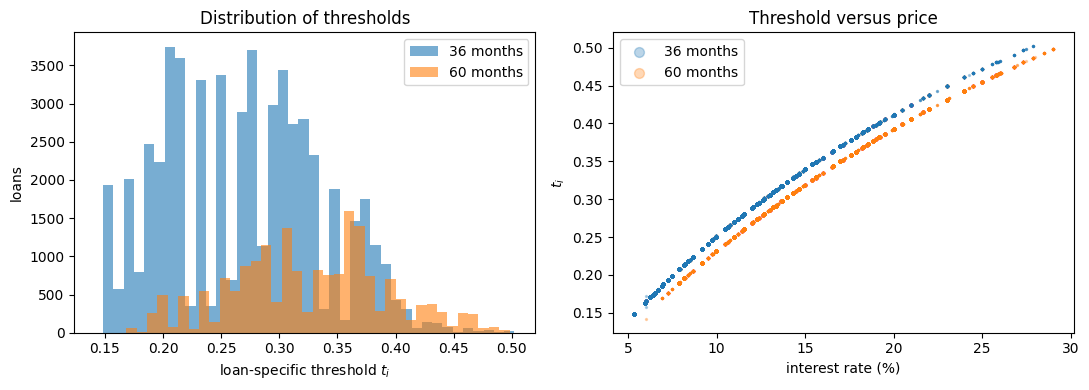

accepted: 82.0%
{36: 0.958, 60: 0.4}


In [5]:
dec['t_i'] = dec['G'] / (dec['G'] + dec['L'])
dec['accept'] = dec['proba_lasso'] < dec['t_i']
assert ((dec['exp_profit'] > 0) == dec['accept']).all()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for T, g in dec.groupby('T'):
    ax[0].hist(g['t_i'], bins=40, alpha=0.6, label=f'{T} months')
    ax[1].scatter(g['int_rate'], g['t_i'], s=2, alpha=0.3, label=f'{T} months')
ax[0].set_xlabel('loan-specific threshold $t_i$'); ax[0].set_ylabel('loans'); ax[0].legend()
ax[1].set_xlabel('interest rate (%)'); ax[1].set_ylabel('$t_i$'); ax[1].legend(markerscale=5)
ax[0].set_title('Distribution of thresholds'); ax[1].set_title('Threshold versus price')
plt.tight_layout()
fig.savefig(f'{FIG}/thresholds.png', dpi=150, bbox_inches='tight'); plt.show()

print(f"accepted: {dec['accept'].mean():.1%}")
print(dec.groupby('T')['accept'].mean().round(3).to_dict())

## 4. Comparing policies, in realised dollars

Four policies, all evaluated on realised profit over the test set:

1. **Accept all** — what Lending Club actually did with these loans: every one of them was granted.
2. **Model rule** — $p_i < t_i$. Nothing is tuned on the test set: the probabilities come from the
   lasso and the parameters from the training set.
3. **Lending Club grades, same volume** — accept the best sub-grades (A1, A2, …) until the same
   number of loans as the model rule is granted. At equal volume, the comparison isolates the
   quality of the selection.
4. **Lasso probability, same volume** — accept the lowest $p_i$ until the same volume. Compared to
   the model rule, this isolates what the *dollar* information (rates, amounts) adds to a pure risk
   ranking.

Profit alone is not enough: a policy that lends less earns less in total but may earn more per
dollar. Both are reported, with the acceptance rate and the default rate among accepted loans.

In [6]:
def summary(mask, name):
    d = dec[mask]
    return {'policy': name,
            'accepted': mask.mean(),
            'default rate': d['y'].mean(),
            'lent ($M)': d['funded_amnt'].sum() / 1e6,
            'profit ($M)': d['real_profit'].sum() / 1e6,
            'return on lent': d['real_profit'].sum() / d['funded_amnt'].sum()}

n_rule = int(dec['accept'].sum())
shuffled = dec.sample(frac=1, random_state=0)     # random order within tied grades
order_lc = shuffled.sort_values('sub_grade', kind='stable').index
order_p  = dec.sort_values('proba_lasso').index

accept_all = pd.Series(True, index=dec.index)
accept_lc  = dec.index.isin(order_lc[:n_rule])
accept_p   = dec.index.isin(order_p[:n_rule])

policies = pd.DataFrame([
    summary(accept_all, 'accept all'),
    summary(dec['accept'], 'model rule'),
    summary(accept_lc, 'LC grades, same volume'),
    summary(accept_p, 'lasso p, same volume'),
]).set_index('policy')
policies.style.format({'accepted': '{:.1%}', 'default rate': '{:.1%}', 'lent ($M)': '{:.1f}',
                       'profit ($M)': '{:.2f}', 'return on lent': '{:.2%}'})

,accepted,default rate,lent ($M),profit ($M),return on lent
policy,,,,,
accept all,100.0%,20.2%,1096.2,37.33,3.41%
model rule,82.0%,15.7%,849.8,51.29,6.04%
"LC grades, same volume",82.0%,15.8%,862.6,46.82,5.43%
"lasso p, same volume",82.0%,14.9%,846.3,53.87,6.37%


### Profit curves: every acceptance rate at once

The table compares policies at one volume. The curves compare them at **all** volumes: loans are
sorted by each ordering, and the cumulative realised profit is plotted against the share accepted.

- **Expected profit** $\mathbb{E}[\Pi_i]$: the model rule's own ordering. The x-axis counts
  loans, so loans are ranked by expected profit per loan, not per dollar lent: with a fixed number
  of loans to grant, the best choice is the loans that earn the most in expectation.
- **Lasso probability**: pure risk ranking.
- **Lending Club sub-grade**: the platform's ranking.

The red dot is the model rule. Each curve's maximum is also marked, but it is an **oracle**: it is
read off the test set, so it is optimistic by construction. The model rule, which chose its
operating point without looking at the test set, should land close to that maximum if the ex-ante
profit model is sound.

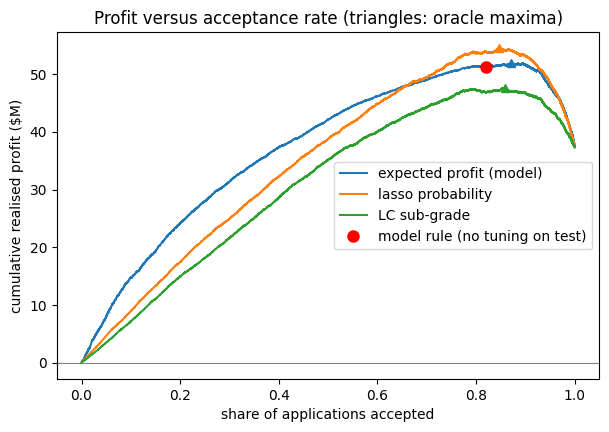

In [7]:
orders = {'expected profit (model)': dec.sort_values('exp_profit', ascending=False).index,
          'lasso probability': order_p,
          'LC sub-grade': order_lc}

fig, ax = plt.subplots(figsize=(7, 4.5))
for name, order in orders.items():
    cp = dec.loc[order, 'real_profit'].cumsum().values / 1e6
    x = np.arange(1, len(cp) + 1) / len(cp)
    line, = ax.plot(x, cp, label=name)
    k = cp.argmax()
    ax.plot(x[k], cp[k], marker='^', color=line.get_color())
ax.plot(dec['accept'].mean(), summary(dec['accept'], '')['profit ($M)'],
        'o', color='red', ms=8, label='model rule (no tuning on test)')
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel('share of applications accepted'); ax.set_ylabel('cumulative realised profit ($M)')
ax.set_title('Profit versus acceptance rate (triangles: oracle maxima)')
ax.legend()
fig.savefig(f'{FIG}/profit_curve.png', dpi=150, bbox_inches='tight'); plt.show()

## 5. By loan term

Censoring biases every 60-month quantity in the same direction (notebook 01, §6 and §9 bis):

| Quantity | Effect of censoring on 60-month loans |
|---|---|
| Probability of default | overestimated (defaults over-represented) |
| Loss rate | overestimated (only early defaults) |
| $\kappa$ | underestimated: no 60-month loan issued in 2015 could reach maturity by end-2018, so every "repaid" one was an early repayment |

The rule therefore refuses too many 60-month loans, and the realised profit of 60-month loans in
this sample is itself pessimistic. The results must be read **separately by term**, and the
60-month figures as a pessimistic bound.

In [8]:
rows = []
for T in sorted(dec['T'].unique()):
    m = dec['T'] == T
    for name, mask in [('accept all', m), ('model rule', m & dec['accept'])]:
        r = summary(mask, name)
        r['accepted'] = mask.sum() / m.sum()
        rows.append({'term': T, **r})
pd.DataFrame(rows).set_index(['term', 'policy']).style.format(
    {'accepted': '{:.1%}', 'default rate': '{:.1%}', 'lent ($M)': '{:.1f}',
     'profit ($M)': '{:.2f}', 'return on lent': '{:.2%}'})

## 6. Is the difference real? Paired bootstrap

The test set is one sample of 75,000 loans; another sample would give other dollar figures. We
resample the test loans with replacement 2,000 times and recompute, **on the same resample**, the
profit difference between two policies. Pairing matters: both policies are evaluated on the same
loans, so the noise they share cancels out, and the interval measures only their difference.

Per loan, the difference between the model rule and "accept all" is $-\,\text{profit}_i$ if the rule
refuses the loan, and 0 otherwise: the rule's whole contribution is the loans it turns down.

If the 95 % interval excludes zero, the gain is not an accident of this particular test set.

In [9]:
rng = np.random.default_rng(0)
B, n = 2000, len(dec)
profit = dec['real_profit'].values
rule = dec['accept'].values

comparisons = {
    'model rule - accept all':      profit * (rule.astype(float) - 1.0),
    'model rule - LC grades (same volume)': profit * (rule.astype(float) - accept_lc.astype(float)),
    'model rule - lasso p (same volume)':   profit * (rule.astype(float) - accept_p.astype(float)),
    'lasso p - LC grades (same volume)':    profit * (accept_p.astype(float) - accept_lc.astype(float)),
}
rows = []
for name, diff in comparisons.items():
    boot = np.array([diff[rng.integers(0, n, n)].sum() for _ in range(B)]) / 1e6
    lo, hi = np.percentile(boot, [2.5, 97.5])
    rows.append({'comparison': name, 'difference ($M)': diff.sum() / 1e6,
                 '95% CI low': lo, '95% CI high': hi})
pd.DataFrame(rows).set_index('comparison').round(2)

,difference ($M),95% CI low,95% CI high
comparison,,,
model rule - accept all,13.96,12.17,15.70
model rule - LC grades (same volume),4.47,2.86,6.17
model rule - lasso p (same volume),-2.58,-3.56,-1.61
lasso p - LC grades (same volume),7.05,5.63,8.52


## Takeaways for the README

- The decision rule is the course's cost threshold with **loan-specific costs**: $p_i < G_i/(G_i+L_i)$.
  The amount lent cancels, so the threshold depends only on price and term — it rises with the rate.
- Profit is computed twice, with different information: ex ante to decide, ex post to evaluate.
- The ex-ante profit model, estimated on the training set, matches realised profit on the test set
  within 2 %, by term and by outcome.
- The rule refuses 18 % of loans and lifts profit from 37.3 to 51.3 M\$ (+14.0 M\$, 95 % CI
  [12.2, 15.7]); at equal volume it beats Lending Club's grades by 4.5 M\$ [2.9, 6.2], and the
  lasso score alone beats them by 7.1 M\$ [5.6, 8.5].
- Ranking by risk alone beats the dollar-aware rule by 2.6 M\$ [1.6, 3.6]: the average profit
  parameters overvalue expensive loans, which are prepaid more often (notebook 01, §9 bis
  diagnostic). Parameters by rate band are the natural extension.
- Every 60-month figure is biased pessimistically by censoring; results are read by term.